In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os
import contractions
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import TruncatedSVD
import gensim.downloader as api
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import SGD
import joblib

In [ ]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
test_labels_df = pd.read_csv('data/test_labels.csv')

In [3]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [5]:
train.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [6]:
# filter comments that contain a hashtag and are toxic or severe_toxic
mask_hashtag = train['comment_text'].str.contains(r'#\w+', regex=True, na=False)
mask_toxic = (train['toxic'] == 1) | (train['severe_toxic'] == 1)

hashtag_toxic_comments = train.loc[mask_hashtag & mask_toxic, ['id', 'comment_text', 'toxic', 'severe_toxic']].copy()

# quick checks
print(f"Found {len(hashtag_toxic_comments)} comments with hashtags that are toxic or severe_toxic")
hashtag_toxic_comments.head(40)['comment_text']

Found 59 comments with hashtags that are toxic or severe_toxic


10368     Dare send messages like this. You are the caus...
14030     "\n\nThe only reason my IP showed is that this...
14608     "Saab lofton was a radio personality for about...
15854     "\nLOL, rest assured there is nothing you can ...
17195     "\n\nHi. It's from the same user who was chang...
17524     Yea Boi \n\nHello you took away my edit of Vic...
18551     That's complete bullshit.  Your comments User_...
19074     Once\nThe song is due to chart at #1 in the UK...
23751     "::Nice wording there.  That's the point.  It'...
28206     Your harassment of me\n\nCease your wikistalki...
28757     You are  really a dishonest person \n\nI've ju...
29265     #penisgate\n\nShouldn't this article mention t...
31990     -Aubrey's #1 fan\n\nWow guy, don't get so work...
32287     "\n\nThe dick who is editing with policy is al...
43308     "\n If I was rude https://www.youtube.com/watc...
43476     Re: Talk:Main Page#Augustus \n\nWP:CIVIL; WP:P...
46135                              Fu*k 

We will not remove stopwords as that will ruin sentence structure, thus making CNN not catch the context

We will not remove punctuations because cnn can learn bigram and trigram filters

We are using embeddings thus stemming is not needed



In [7]:
def expand_contractions(text):
    return contractions.fix(text) # Expand contractions like don't to do not

Normalization is need so that CNN doesnt think loooooool is different to lol

In [8]:
def normalize_repeats(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)  # Words like soooo become soo

In [9]:
newline_re       = re.compile(r'\n')
url_re           = re.compile(r'https?://\S+|www\.\S+')
email_re         = re.compile(r'\S+@\S+')
number_re        = re.compile(r'\d+')
allowed_chars_re = re.compile(r"[^a-zA-Z0-9!?'* ]")
multi_space_re   = re.compile(r'\s+')

In [10]:
def clean_text(text):
    text = text.lower()  # Lowercase
    text = expand_contractions(text)  # Expand contractions
    text = normalize_repeats(text)  # Normalize repeated characters
    text = newline_re.sub(' ', text) # Remove newlines
    text = url_re.sub(' URL ', text)  # Replace URLs
    text = email_re.sub(' EMAIL ', text) # Replace emails
    text = number_re.sub(' NUMBER ', text) # Replace numbers
    text = allowed_chars_re.sub(' ', text) # Keep letters, numbers, ! ? ' *
    text = multi_space_re.sub(' ', text).strip() # Remove extra spaces
    return text

In [11]:
train['comment_text'] = train['comment_text'].apply(clean_text)
test['comment_text']  = test['comment_text'].apply(clean_text)

train['comment_text'].head()

0    explanation why the edits made under my userna...
1    d'aww! he matches this background colour i am ...
2    hey man i am really not trying to edit war it ...
3    more i cannot make any real suggestions on imp...
4    you sir are my hero any chance you remember wh...
Name: comment_text, dtype: object

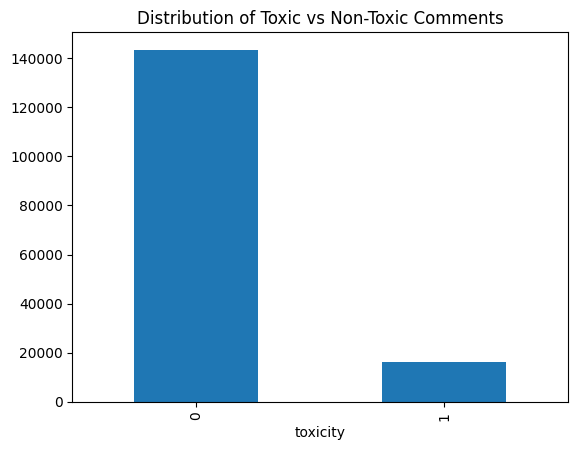

In [ ]:
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
train['toxicity'] = train[LABEL_COLS].max(axis=1)

train['toxicity'].value_counts().plot(kind='bar')
plt.title('Distribution of Toxic vs Non-Toxic Comments')
plt.show()

In [13]:
MAX_VOCAB = 50000
MAX_LEN = 200
EMBEDDING_DIM = 300

In [ ]:
word2vec = api.load("word2vec-google-news-300")

In [15]:
def balance_and_split(df):
    toxic = df[df['toxicity'] == 1]
    non_toxic = df[df['toxicity'] == 0].sample(len(toxic))  # balance

    df_bal = pd.concat([toxic, non_toxic]).sample(frac=1)   # shuffle

    X = df_bal['comment_text']
    y = df_bal['toxicity']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=None       # IMPORTANT
    )
    tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
    X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

    return X_train, X_test, y_train, y_test, X_train_seq, X_test_seq, tokenizer

In [ ]:
def create_cnn_model(embedding_layer, X_train_seq, y_train, input_layer, validation_data=None, epochs=5, batch_size=64):
    conv3 = Conv1D(128, 3, activation='relu')(embedding_layer)
    pool3 = GlobalMaxPooling1D()(conv3)

    conv4 = Conv1D(128, 4, activation='relu')(embedding_layer)
    pool4 = GlobalMaxPooling1D()(conv4)

    conv5 = Conv1D(128, 5, activation='relu')(embedding_layer)
    pool5 = GlobalMaxPooling1D()(conv5)

    merged = Concatenate()([pool3, pool4, pool5])
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=0.005, momentum=0.9), metrics=['accuracy'])

    if validation_data is None:
        history = model.fit(
            X_train_seq,
            y_train,
            epochs=epochs,
            batch_size=batch_size
        )
    else:
        history = model.fit(
            X_train_seq,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=validation_data
        )
    
    return model, history

In [17]:
def save_model(model, modelName, history, historyName):
    model.save(f'models/{modelName}')

    # Save training history
    joblib.dump(history.history, f'models/{historyName}')
    print(f"Saved: models/{modelName}, models/{historyName}")

In [18]:
def load_classifier_model(modelName, historyName):
    model = load_model(f'models/{modelName}')

    history = joblib.load(f'models/{historyName}')

    return model, history

In [19]:
def calc_specificity_fdr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel() # ravel converts the multi dimensional array to 1D

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fdr = fp / (fp + tp) if (fp + tp) > 0 else 0

    return specificity, fdr

In [ ]:
os.makedirs('models', exist_ok=True)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train['comment_text'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train['comment_text']), maxlen=MAX_LEN, padding='post')
y_train = train['toxicity'].values

word_index = tokenizer.word_index
num_words = min(MAX_VOCAB, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
embedding_index = word2vec

for word, i in word_index.items():
    if i >= MAX_VOCAB:
        continue
    if word in embedding_index:
        embedding_matrix[i] = embedding_index[word]

input_layer = Input(shape=(MAX_LEN,))
embedding_layer_fix = Embedding(
    num_words,
    EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False
)(input_layer)

cnn_fix_model, history = create_cnn_model(
    embedding_layer_fix,
    X_train_seq, y_train,
    input_layer,
    validation_data=None,
    epochs=5,
    batch_size=64
)

save_model(cnn_fix_model, 'cnn_fix_model.keras', history, 'cnn_fix_history.pkl')

In [ ]:
test_df = pd.merge(test, test_labels_df, on='id')

valid_mask = (test_df[LABEL_COLS] >= 0).all(axis=1)
test_df = test_df[valid_mask].copy()

test_df['toxicity'] = test_df[LABEL_COLS].max(axis=1).astype(int)

X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['comment_text']), maxlen=MAX_LEN, padding='post')
y_test = test_df['toxicity'].values.astype(int)

y_pred = (cnn_fix_model.predict(X_test_seq) > 0.5).astype('int32').ravel()

acc = accuracy_score(y_test, y_pred)
spec, fdr = calc_specificity_fdr(y_test, y_pred)

metrics_dict = {
  'Metric': ['Accuracy', 'Specificity', 'False Discovery Rate'],
  'Value': [float(acc), float(spec), float(fdr)]
}
df_metrics = pd.DataFrame(metrics_dict)
print(df_metrics)

df_metrics.to_csv('cnn_fix_test_metrics.csv', index=False)

test_results = test_df[['id']].copy()
test_results['y_true'] = y_test
test_results['y_pred'] = y_pred
test_results.to_csv('cnn_fix_test_predictions.csv', index=False)